# Environment

The core workflow requires Python, PyTorch, NumPy, and a CUDA GPU for practical large-matrix runs. Install the notebook dependencies with:

```bash
pip install -e ".[notebook]"
```

Optional RAPIDS support accelerates parquet ingestion. Without it, the notebook falls back to pandas/NumPy; the matrix construction, AdaptGrow SymNMF, spherical K-means, and adjusted-Rand-index calculations remain PyTorch/NumPy based.

# Clustering Synthetic Dependence Matrices Through Time with Symmetric NMF

This self-contained developer example transforms a synthetic return stream into time-varying correlation (CORR) and tail-pairwise dependence (TPDM) matrices. It then clusters those matrices with Symmetric NMF and spherical K-means, measuring agreement and stability with adjusted Rand index (ARI). The AdaptGrow solver and matrix constructions follow Ghita et al., [Low-Rank Dependence Decomposition via Accelerated Symmetric Non-negative Matrix Factorization](https://arxiv.org/abs/2607.24518), arXiv:2607.24518 (2026).

## Scope

The notebook demonstrates reusable numerical primitives: synthetic data generation, dependence-matrix construction, rank selection, non-negative factorization, and clustering. Its inputs are synthetic and its outputs are generic factors and clusters. It does not define financial factors, neutralization, shrinkage, portfolio rules, or investment decisions.

## Steps

1. Generate and load synthetic returns.
2. Estimate CORR and TPDM matrices across windows.
3. Select rank `k` from a spectrum probe.
4. Factorize matrices with AdaptGrow SymNMF.
5. Compare spherical K-means assignments and ARI stability.

## Prerequisites

- Python with PyTorch, NumPy, and `pyarrow`; CUDA is recommended.
- Optional RAPIDS packages accelerate parquet ingestion but are not required.
- The default `N = 50,000` requires substantial GPU memory. For an interactive run, set `N = 1,000` or lower in the configuration cell.

```bash
pip install -e ".[notebook]"
```

In [15]:
import os
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

# True fp32 throughout: disable the TF32 tensor-core path so every matmul
# (AdaptGrow's gradient products and spherical K-means' XCᵀ cosines) runs in full
# single precision. On heavy-tailed matrices (the TPDM) TF32's ~10-bit mantissa
# measurably degrades the clustering (within-cluster dispersion blows up); fp32
# keeps it faithful and matches the production benchmark solvers.
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.set_float32_matmul_precision("highest")

# GPU ingest is optional: cuDF reads the returns matrix on-GPU, with a pandas fallback so the
# notebook also runs torch-only. The solvers and the metric are pure PyTorch / NumPy either way.
try:
    import cudf
    HAS_CUDF = True
except Exception:
    HAS_CUDF = False

SEED = 7
N = 50_000              # instruments (~10 GB dense fp32: top of the single-GPU range; lower for a quick run)
K = 24                  # planted ground-truth #sectors (GICS-industry-group granularity for a
                        # 50k universe); the spectral k-selection recovers it (k unknown in production)
L = 11_960              # stream length (observations); set so the slide yields exactly 250 windows
WIN = 2_000             # rolling-window width used to estimate each matrix
STRIDE = 40             # step between windows -> 250 rolling versions of S_t (~one per trading day in a year)
LAG = WIN // STRIDE     # =50: stability compares windows one full width apart. Consecutive
                        # windows overlap by all but one stride, so a reclassification entering
                        # the window gradually barely moves ARI(t-1, t); ARI(t-LAG, t) lets the
                        # accumulated membership change register as a real dip.
TAIL_Q = 0.10           # top fraction of observations used for the TPDM (joint tail)

# Planted events in the synthetic fixture, used both to generate the returns matrix and to mark the
# known structural changes on the plots. They have no analog in real data.
BREAK_T = 6_000         # a sector reclassification happens mid-stream
CRISIS = (9_000, 9_600) # a tail-stress episode spans these observations
STRESS_SECTORS = (0, 1, 2, 3)   # sectors that quietly co-crash in the tail during the crisis

# Returns matrix on disk. In production an upstream pipeline writes the returns matrix and the
# notebook only reads it. Here the offline generator (make_returns_matrix.py) writes it once
# (Step 1), then we load it on the GPU the same way production would. REGENERATE=False reuses
# a returns matrix already on disk.
DATA_DIR = "data"
RETURNS_PARQUET = os.path.join(DATA_DIR, "returns.parquet")
GT_PARQUET = os.path.join(DATA_DIR, "ground_truth.parquet")
REGENERATE = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
})
print(f"device = {device}  |  n = {N}, k = {K}, stream length = {L}")
print(f"cuDF ingest: {'available' if HAS_CUDF else 'not found (using pandas fallback)'}")

device = cuda  |  n = 50000, k = 24, stream length = 11960
cuDF ingest: available


## Step 1: Generate synthetic returns and load them

The notebook uses a synthetic, heavy-tailed returns fixture so its expected structure is known. The helper in `adaptgrow.fixtures` writes this fixture to `data/` as parquet; the equivalent checkout command is:

```bash
python scripts/make_returns_matrix.py
```

Set `REGENERATE = False` in the configuration cell to reuse an existing fixture. Optional cuDF ingest reads parquet directly on the GPU; the notebook falls back to pandas when cuDF is unavailable.

The synthetic stream has block structure, a controlled reclassification, and a controlled tail-stress episode. They exist only to demonstrate the numerical workflow; no financial interpretation or downstream decision rule is included.

In [16]:
from adaptgrow.fixtures import generate_returns_matrix

# Generate a deterministic synthetic returns fixture and persist it to parquet.
# The notebook passes its own config so the on-disk returns matrix matches the analysis that follows.
t0 = time.perf_counter()
msg = generate_returns_matrix(DATA_DIR, n=N, k=K, L=L, break_t=BREAK_T, crisis=CRISIS,
                     stress_sectors=STRESS_SECTORS, seed=SEED, regenerate=REGENERATE,
                     device=device)
if device.type == "cuda":
    torch.cuda.empty_cache()                # drop generator buffers so Step 1b is a genuine GPU reload
print(f"{msg}  ({time.perf_counter() - t0:.2f}s)")

wrote returns matrix (50000, 11960) to data/ via cuDF (GPU) -> parquet  (55.94s)


In [17]:
def load_returns_matrix():
    """Production ingest path: read the returns matrix onto the GPU.
    cuDF reads the parquet on-GPU and `.values` (a cuPy array) is handed to torch via DLPack
    with no host round-trip. Falls back to a pandas read so the notebook runs torch-only too."""
    if HAS_CUDF:
        try:
            R = torch.from_dlpack(cudf.read_parquet(RETURNS_PARQUET).values.astype("float32")).to(device)
            sectors_np = cudf.read_parquet(GT_PARQUET)["sector"].to_numpy()
            return R, sectors_np, "cuDF -> torch (GPU)"
        except Exception:
            pass
    import pandas as pd
    R = torch.as_tensor(pd.read_parquet(RETURNS_PARQUET).to_numpy(),
                        dtype=torch.float32, device=device)
    sectors_np = pd.read_parquet(GT_PARQUET)["sector"].to_numpy()
    return R, sectors_np, "pandas -> torch"


t0 = time.perf_counter()
R, sectors_np, src = load_returns_matrix()
windows = [(s, s + WIN) for s in range(0, L - WIN + 1, STRIDE)]
mids = [(a + b) // 2 for a, b in windows]
if device.type == "cuda":
    torch.cuda.synchronize()
print(f"loaded returns R: {tuple(R.shape)} on {R.device} via {src} "
      f"({time.perf_counter() - t0:.2f}s)")
print(f"{len(windows)} rolling windows of width {WIN} (stride {STRIDE}); "
      f"sector sizes: {np.bincount(sectors_np).tolist()}")

loaded returns R: (50000, 11960) on cuda:0 via cuDF -> torch (GPU) (5.18s)
250 rolling windows of width 2000 (stride 40); sector sizes: [2066, 2031, 2079, 2101, 2059, 2064, 2107, 2107, 2100, 2119, 2101, 2058, 2021, 2027, 2121, 2037, 2129, 2049, 2064, 2115, 2097, 2124, 2139, 2085]


## Step 2: Estimate a CORR matrix and a TPDM per window

For each rolling window we build two symmetric, non-negative, unit-diagonal matrices from the same synthetic returns:

- **Correlation:** absolute Pearson correlation over the full window.
- **TPDM:** a tail-pairwise dependence estimator that emphasizes observations with large joint radial magnitude.

The estimators are written in PyTorch so each matrix and its downstream solver share a device, dtype, and memory allocator.

In [18]:
def corr_matrix(X):
    """Absolute Pearson correlation of rows of X (n x W), symmetric, unit diagonal."""
    Xc = X - X.mean(1, keepdim=True)
    cov = Xc @ Xc.T
    d = torch.sqrt(torch.diag(cov)); d[d == 0] = 1.0
    C = cov / torch.outer(d, d)
    return (0.5 * (C + C.T)).abs()


def _to_frechet(X, eps=1e-12):
    """Standardize each instrument's window to unit-Fréchet margins on the *loss*
    tail. Returns are signed, but the TPDM is an extreme-value object defined for
    regularly-varying vectors on a common positive scale -- so the estimator (not
    the raw returns matrix) restores positivity here. Each row is rank-transformed to
    uniform and mapped through the Fréchet quantile, so the largest losses (large
    -X) become the largest positive values; scale and sign of the input no longer
    matter. This is the standard EVT marginal transform the TPDM assumes."""
    W = X.shape[1]
    ranks = (-X).argsort(dim=1).argsort(dim=1).float()      # ascending rank of losses, 0..W-1
    U = (ranks + 1.0) / (W + 1.0)                           # uniform in (0, 1)
    return (-1.0 / torch.log(U)).clamp(min=eps, max=1e6)    # unit-Fréchet quantile (positive)


def tpdm_matrix(X, qt=TAIL_Q):
    """Tail Pairwise Dependence Matrix from the joint loss-tail of X (n x W).
    X may be signed; positivity is restored internally via _to_frechet."""
    Xp = _to_frechet(X)                                     # signed returns -> positive RV margins
    n, W = Xp.shape
    norms = Xp.norm(dim=0)
    n_exc = min(max(int(W * qt), 30), W - 1)
    idx = torch.topk(norms, n_exc).indices                  # observations with the largest joint magnitude (the joint tail)
    Wt = Xp[:, idx] / norms[idx]                            # angular components
    S = (n / n_exc) * (Wt @ Wt.T)
    d = torch.sqrt(torch.diag(S)); d[d == 0] = 1.0
    S = S / torch.outer(d, d)
    S.fill_diagonal_(1.0)
    return S.clamp(min=0)


# sanity check on the first window
Sc0, St0 = corr_matrix(R[:, :WIN]), tpdm_matrix(R[:, :WIN])
print(f"correlation: shape {tuple(Sc0.shape)}, diag~{torch.diag(Sc0).mean():.2f}, "
      f"symmetric={torch.allclose(Sc0, Sc0.T, atol=1e-5)}")
print(f"TPDM       : shape {tuple(St0.shape)}, diag~{torch.diag(St0).mean():.2f}, "
      f"symmetric={torch.allclose(St0, St0.T, atol=1e-5)}")
del Sc0, St0

correlation: shape (50000, 50000), diag~1.00, symmetric=True
TPDM       : shape (50000, 50000), diag~1.00, symmetric=True


## Step 3: Choose the rank `k`

`k` is both the factorization rank and number of soft clusters. Because reconstruction error decreases monotonically as rank grows, the notebook estimates `k` from a randomized top-eigenvalue probe of the first matrix:

- a spectral-gap heuristic;
- the rank needed to capture a target share of the trace; and
- a significance floor to avoid selecting numerical noise.

The chosen `K_HAT` is held fixed across windows so the cluster assignments are comparable over time. The planted rank is used only to validate this synthetic example.

planted k = K = 24
correlation : gap picks k=24 (ratio 36x); energy@95% k=24; top-K trace = 98.4%
TPDM        : gap picks k=24 (ratio 29x); energy@95% k=23; top-K trace = 98.9%
-> rank selection uses the spectral gap and trace-energy diagnostics above.


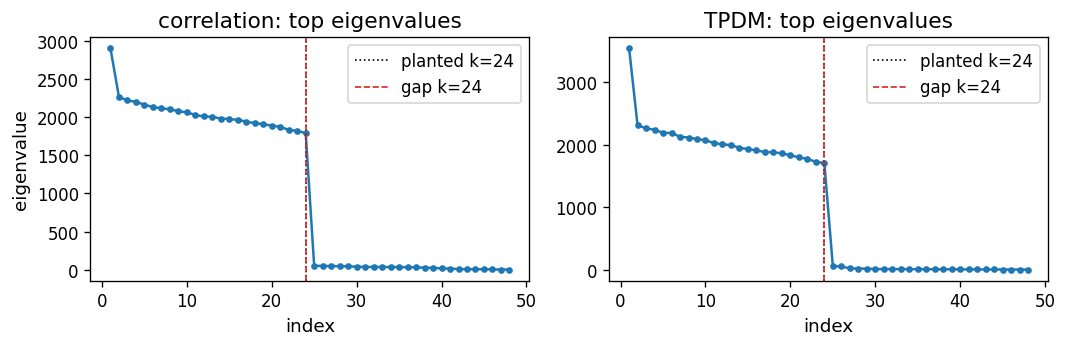


using K_HAT = 24 for all clustering downstream (correlation gap; TPDM gap agrees at k=24; planted k=24)


In [19]:
# Pin the symmetric-eig backend to cuSOLVER (PyTorch's CUDA LAPACK library); without this
# PyTorch chooses cuSOLVER or MAGMA by heuristic. No-op on CPU-only builds.
if torch.cuda.is_available():
    torch.backends.cuda.preferred_linalg_library("cusolver")

def top_eigvals(S, p=48, n_power=3, gen=None):
    """Randomized top-p eigenvalues of symmetric S: a few S@X matmuls + a small p x p eig.
    Avoids the O(n^3) full eigendecomposition, which is infeasible at this scale."""
    n = S.shape[0]; p = min(p, n - 1)
    Q, _ = torch.linalg.qr(S @ torch.randn(n, p, device=S.device, generator=gen))
    for _ in range(n_power):                       # subspace iteration sharpens the estimate
        Q, _ = torch.linalg.qr(S @ Q)
    B = Q.T @ (S @ Q)                              # p x p Rayleigh quotient
    return torch.linalg.eigvalsh(0.5 * (B + B.T)).flip(0).clamp(min=0)   # descending; eigvalsh -> cuSOLVER on GPU


def choose_rank(S, p=48, energy=0.95, rel_floor=1e-3, gen=None):
    """Estimate k from the spectrum: gap ratio over the *significant* eigenvalues, plus
    trace-energy (tr(S) = n for unit-diagonal S). The significance floor keeps the
    randomized noise tail (driven toward zero by the subspace iteration) from producing
    a spurious gap deep in the bulk."""
    ev = top_eigvals(S, p=p, gen=gen)
    keep = max(int((ev > rel_floor * ev[0]).sum().item()), 2)   # eigenvalues above noise
    ratios = ev[:-1] / (ev[1:] + 1e-12)
    ratios[0] = 0.0                                             # ignore the trivial leading drop
    # Search the gap *strictly inside* the significant block. ratios[keep-1] is the
    # cliff from the last kept eigenvalue into the subspace-sharpened noise tail
    # (a ~1e13 ratio to a near-zero value); including it makes the detector pick the
    # noise edge instead of the structural gap. Excluding it recovers the true k.
    hi = max(keep - 1, 2)
    k_gap = int(torch.argmax(ratios[:hi]).item()) + 1          # largest gap inside the signal block
    cap = torch.cumsum(ev, 0) / S.shape[0]                      # fraction of total trace in top-i
    k_energy = int((cap < energy).sum().item()) + 1
    return {"k_gap": k_gap, "gap_ratio": float(ratios[:keep].max()),
            "k_energy": k_energy, "cap_at_K": float(cap[K - 1])}, ev.cpu().numpy()


gen_k = torch.Generator(device=device).manual_seed(SEED)
S0c, S0t = corr_matrix(R[:, :WIN]), tpdm_matrix(R[:, :WIN])
info_c, ev_c = choose_rank(S0c, gen=gen_k)
info_t, ev_t = choose_rank(S0t, gen=gen_k)
del S0c, S0t
print(f"planted k = K = {K}")
print(f"correlation : gap picks k={info_c['k_gap']} (ratio {info_c['gap_ratio']:.0f}x); "
      f"energy@95% k={info_c['k_energy']}; top-K trace = {info_c['cap_at_K']*100:.1f}%")
print(f"TPDM        : gap picks k={info_t['k_gap']} (ratio {info_t['gap_ratio']:.0f}x); "
      f"energy@95% k={info_t['k_energy']}; top-K trace = {info_t['cap_at_K']*100:.1f}%")
print("-> rank selection uses the spectral gap and trace-energy diagnostics above.")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.0))
for a, ev, info, name in [(ax[0], ev_c, info_c, "correlation"), (ax[1], ev_t, info_t, "TPDM")]:
    a.plot(range(1, len(ev) + 1), ev, "o-", ms=3)
    a.axvline(K, color="k", ls=":", lw=1, label=f"planted k={K}")
    a.axvline(info["k_gap"], color="C3", ls="--", lw=1, label=f"gap k={info['k_gap']}")
    a.set_title(f"{name}: top eigenvalues"); a.set_xlabel("index"); a.legend()
ax[0].set_ylabel("eigenvalue"); plt.tight_layout(); plt.show()

# The pipeline uses the spectral estimate from here on (not the planted K). Both matrices'
# gaps agree at this scale; we take the correlation gap as the operating rank.
K_HAT = info_c["k_gap"]
print(f"\nusing K_HAT = {K_HAT} for all clustering downstream "
      f"(correlation gap; TPDM gap agrees at k={info_t['k_gap']}; planted k={K})")

## Step 4: Factorize with SymNMF and derive clusters

We approximate each dependence matrix as `S ≈ H Hᵀ` with `H ≥ 0`, where each row of `H` is a soft membership profile. Hard assignments are the row-wise `argmax` of `H`.

The notebook minimizes `f(H) = ‖S − HHᵀ‖_F²` with `AdaptGrow` from `adaptgrow.py`. It is a PyTorch implementation that works on whichever device holds `S`.

Each window starts from the same deterministic random initialization so the comparison reflects changes in the synthetic matrices rather than a changing initialization.

In [20]:
from adaptgrow import AdaptGrow


def symnmf_factorize(S, k, n_iter=400, seed=SEED):
    """Factor a symmetric matrix with AdaptGrow on the device holding ``S``.

    Each window is factored independently from a fixed-seed random start so the
    clustering comparison reflects the input matrices rather than an earlier
    solution.

    The init is **scale-matched** to S (||H0 H0^T||_F = ||S||_F, computed cheaply
    via the k x k Gram ||H0^T H0||_F). This is what keeps the cold start cheap: an
    unscaled |rand| H0 sits ~k-fold too large on the diagonal, and AdaGrad then
    wastes hundreds of iterations just rescaling H before any structure appears
    (the reconstruction sits at E ~ 1 the whole time). With the matched init the
    factorization converges in a few hundred steps."""
    torch.manual_seed(seed)
    H0 = torch.abs(torch.rand(S.shape[0], k, device=S.device, dtype=S.dtype))
    H0 = (H0 * torch.sqrt(torch.norm(S) / torch.norm(H0.T @ H0))).clamp_min_(1e-16)
    return AdaptGrow(lr=2.0, entry_frac=1.0, max_iter=n_iter,
                   grad_tol=1e-4, verbose=False).optimize(S, k, H0=H0)


def stress_cross_dependence(S, labels_np, sectors):
    """Mean off-block dependence between DIFFERENT stressed sectors (a scalar per window)."""
    vals = []
    for i, a in enumerate(sectors):
        for b in sectors[i + 1:]:
            ra = torch.as_tensor(labels_np == a, device=S.device)
            rb = torch.as_tensor(labels_np == b, device=S.device)
            if ra.any() and rb.any():
                vals.append(S[ra][:, rb].mean().item())
    return float(np.mean(vals)) if vals else float("nan")


# Walk the stream once: estimate both matrices per window, factor both with AdaptGrow,
# and record hard clusters plus the cross-sector tail dependence among stressed sectors.
corr_labels, tpdm_labels = [], []
xdep_corr, xdep_tpdm = [], []
ss = list(STRESS_SECTORS)

t0 = time.perf_counter()
for (a, b) in windows:
    Xw = R[:, a:b]
    Sc, St = corr_matrix(Xw), tpdm_matrix(Xw)
    Hc = symnmf_factorize(Sc, K_HAT); corr_labels.append(Hc.argmax(1).cpu().numpy())
    Ht = symnmf_factorize(St, K_HAT); tpdm_labels.append(Ht.argmax(1).cpu().numpy())
    xdep_corr.append(stress_cross_dependence(Sc, sectors_np, ss))
    xdep_tpdm.append(stress_cross_dependence(St, sectors_np, ss))
    del Sc, St
if device.type == "cuda":
    torch.cuda.synchronize()
print(f"factored {len(windows)} windows x 2 matrices at n={N} in "
      f"{time.perf_counter() - t0:.2f}s on {device}")

factored 250 windows x 2 matrices at n=50000 in 1049.82s on cuda


## Step 5: Cluster with spherical K-means

Spherical (cosine) K-means is the second method we run: the fast, hard-assigning workhorse, and the one SymNMF is a continuous relaxation of. A dependence matrix is unit-diagonal, so every row has the same norm and what distinguishes instruments is the *angle* between rows: `S` is a **cosine-Gram similarity matrix**, exactly what spherical K-means consumes. (Euclidean K-means would only be right on an un-standardized covariance, where row norms carry variance; we standardize to unit diagonal.)

We cluster each window's correlation matrix **independently** (fixed-seed init), so the hard partition follows the data window to window — ready to compare against SymNMF once the Rand index is in hand (Step 9). Spherical (cosine) K-means is just Euclidean K-means on L2-normalized rows; we implement it directly in PyTorch so it shares a device with the SymNMF solver.

> **Note:** like SymNMF, spherical K-means is a PyTorch method here. This in-notebook version is the single-GPU reference; the production multi-node version is a PyTorch + `torch.distributed`/NCCL implementation that uses the **same row-sharded layout as `AdaptGrow`** (assignments are row-local; only the `k×n` centroids are `all_reduce`d each iteration). There is no SymNMF or spherical-K-means estimator in cuML today, so both stay on PyTorch.

In [21]:
def spherical_kmeans(X, k, n_iter=100, seed=0, centroids=None, eps=1e-12,
                     tol=1e-4):
    """Spherical (cosine) K-means on rows of X, from a fixed-seed init (or from
    `centroids` if supplied).

    The implementation uses unit-normalized rows, argmax-cosine assignment,
    sum-then-normalize centroid updates, and objective-stagnation convergence.
    It stops when the spherical objective Σ(1 - cos) stops improving (relative
    drop < `tol`) rather than waiting for the hard labels to stop changing. That
    label-equality test never settles on weakly-separated matrices like the TPDM, where a few boundary
    points oscillate between near-tied centroids and the loop runs to the cap; the
    objective plateau is the true fixed point. Runs in true fp32 (TF32 disabled in
    the setup cell). Single-GPU reference; the distributed PyTorch/NCCL version uses
    identical math on the AdaptGrow row-sharded layout (a k×n centroid all_reduce)."""
    g = torch.Generator(device=X.device).manual_seed(seed)
    Xn = X / (X.norm(dim=1, keepdim=True) + eps)
    n = Xn.shape[0]
    C = (Xn[torch.randperm(n, generator=g, device=X.device)[:k]].clone()
         if centroids is None else centroids.clone())
    C = C / (C.norm(dim=1, keepdim=True) + eps)
    labels = torch.full((n,), -1, dtype=torch.long, device=X.device)
    prev_inertia = None
    for _ in range(n_iter):
        cos, new = (Xn @ C.T).max(dim=1)            # assign to nearest centroid
        # clamp: fp32 cosines can drift just past 1.0 for near-collinear rows
        inertia = float((1.0 - cos.clamp(max=1.0)).sum())   # objective Σ(1 - cos)
        changed = int((new != labels).sum())
        labels = new
        # sum-then-normalize update (mean differs only by a per-cluster scalar that
        # unit-normalization removes); empty clusters are reseeded so all k stay alive.
        sums = torch.zeros_like(C).index_add_(0, labels, Xn)
        empty = torch.bincount(labels, minlength=k) == 0
        if empty.any():
            ridx = torch.randint(n, (int(empty.sum()),), generator=g, device=X.device)
            sums[empty] = Xn[ridx]
        C = sums / (sums.norm(dim=1, keepdim=True) + eps)
        if prev_inertia is not None and (
                (prev_inertia - inertia) / max(prev_inertia, eps) < tol
                or changed < 1e-3 * n):
            break
        prev_inertia = inertia
    return labels, C


# Spherical K-means labels per window: each window clustered independently
# (fixed-seed init), so the hard partition follows the data window to window.
# (Cross-method comparison against the SymNMF labels is in Step 9.)
km_labels = []
for (a, b) in windows:
    Sc = corr_matrix(R[:, a:b])
    lab, _ = spherical_kmeans(Sc, K_HAT)
    km_labels.append(lab.cpu().numpy()); del Sc
print(f"spherical K-means (PyTorch): {len(km_labels)} windows clustered (k = {K_HAT})")

spherical K-means (PyTorch): 250 windows clustered (k = 24)


## Step 6: Measure clustering agreement with the Rand index

To ask "are two clusterings the same?" we cannot compare labels directly, since cluster `0` in one fit may be cluster `3` in the next. The **Rand index** counts **pairs of instruments**: the fraction of all pairs that two clusterings agree on (together in both, or apart in both). This is label-permutation invariant.

Even random clusterings share pairs by chance, so the raw index is optimistically high. The **adjusted Rand index (ARI)** subtracts the chance level: `1` for identical clusterings, `≈ 0` for unrelated ones, negative for worse-than-random. We import it from `clustering_metrics.py` (`adjusted_rand_index`), built from the contingency table `n_ij` with pair counts `C(x,2)`. That same `k×k` contingency is the unit of work for the **distributed** ARI: at multi-node scale each rank builds its local table and the global one is a single `k×k` `all_reduce` (`distributed_adjusted_rand_index` in the same module — see Next steps). Keeping the metric in our own module rather than calling cuML means the single-GPU and multi-node paths share one definition:

$$ \mathrm{ARI} = \frac{\sum_{ij}\binom{n_{ij}}{2} - \big[\sum_i\binom{a_i}{2}\sum_j\binom{b_j}{2}\big]/\binom{n}{2}}{\tfrac12\big[\sum_i\binom{a_i}{2}+\sum_j\binom{b_j}{2}\big] - \big[\sum_i\binom{a_i}{2}\sum_j\binom{b_j}{2}\big]/\binom{n}{2}}. $$

In [22]:
from adaptgrow.clustering_metrics import adjusted_rand_index

# Sanity check: ARI is 1 for identical clusterings and ~0 for unrelated ones.
rng = np.random.default_rng(SEED)
x = rng.integers(0, K, size=200); y = rng.integers(0, K, size=200)
print("ARI(x, x)      =", round(adjusted_rand_index(x, x), 6), "(expect 1.0)")
print("ARI(x, random) =", round(adjusted_rand_index(x, y), 4), "(expect ~0)")


def ari(a, b):
    """Adjusted Rand index used everywhere downstream (clustering_metrics.adjusted_rand_index).
    The same module's distributed_adjusted_rand_index is the multi-node version: an identical
    contingency-table definition reduced across ranks with one k x k all_reduce."""
    return adjusted_rand_index(a, b)

ARI(x, x)      = 1.0 (expect 1.0)
ARI(x, random) = -0.0039 (expect ~0)


## Step 7: Stability through time

The operational question is **how much do clusters change over time?** We track `ARI(t−Δ, t)` for both the correlation and the TPDM clustering, comparing each window with the one a full window-width earlier (`Δ = WIN/STRIDE = 50`). Consecutive windows overlap by all but one stride, so a reclassification that enters the window gradually barely moves `ARI(t−1, t)` — each step changes only ~2% of the observations; spacing the comparison by a full width lets the accumulated change register as a real dip. High and flat means structure is holding; a sharp dip means the market reorganized.

We expect a dip at the **reclassification** (`BREAK_T`): instruments genuinely change groups, so both clusterings reshuffle. Through the **tail-stress episode** (`CRISIS`), the hard clusters should stay put (the co-crash is a tail phenomenon, not a relabeling), which is exactly why a stability curve alone is not enough, and we look at the tail directly in Step 8.

**From curve to monitor.** To act on this rather than eyeball it, we overlay a simple **self-calibrating control limit**: treat the calm, pre-break windows as the in-control baseline and flag any later drop beyond `3σ` below it. It needs no hand-set threshold and separates ordinary jitter from a genuine break. Treat it as a *starting point*, not a finished detector: the point of this example is that the GPU-accelerated pipeline makes the stability signal available continuously and at scale; the alerting rule on top is a thin, swappable layer a desk would calibrate on its own break history and backtest.

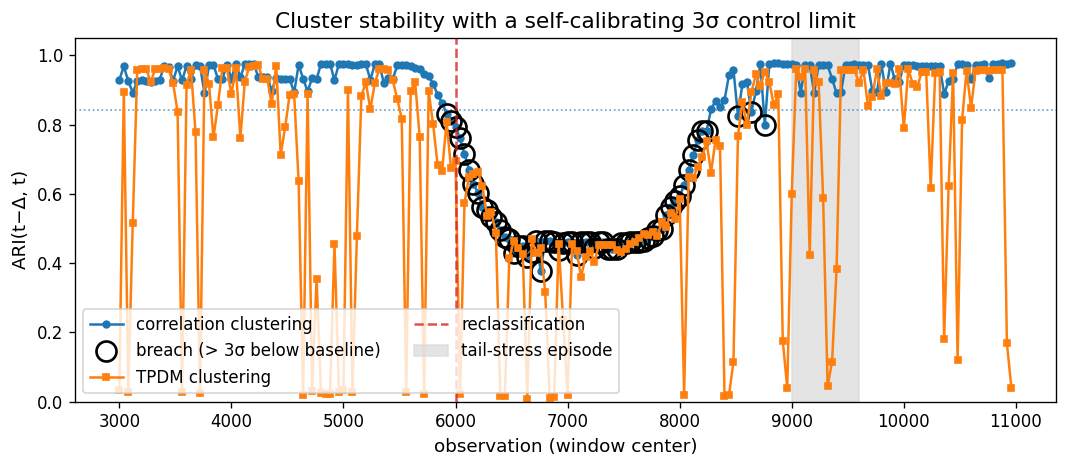

correlation: calm baseline ARI = 0.94, 3σ limit = 0.84; breaches at obs [5920, 5960, 6000, 6040, 6080, 6120, 6160, 6200, 6240, 6280, 6320, 6360, 6400, 6440, 6480, 6520, 6560, 6600, 6640, 6680, 6720, 6760, 6800, 6840, 6880, 6920, 6960, 7000, 7040, 7080, 7120, 7160, 7200, 7240, 7280, 7320, 7360, 7400, 7440, 7480, 7520, 7560, 7600, 7640, 7680, 7720, 7760, 7800, 7840, 7880, 7920, 7960, 8000, 8040, 8080, 8120, 8160, 8200, 8240, 8520, 8640, 8760]
TPDM       : calm baseline ARI = 0.70, 3σ limit = -0.34; breaches at obs none


In [23]:
corr_ari = [ari(corr_labels[t - LAG], corr_labels[t]) for t in range(LAG, len(windows))]
tpdm_ari = [ari(tpdm_labels[t - LAG], tpdm_labels[t]) for t in range(LAG, len(windows))]
step_mids = mids[LAG:]


def mark_episodes(ax):
    ax.axvline(BREAK_T, color="C3", ls="--", alpha=0.8, label="reclassification")
    ax.axvspan(CRISIS[0], CRISIS[1], color="0.85", alpha=0.7, label="tail-stress episode")


# Self-calibrating control limit: calibrate on the calm, pre-break windows and flag any
# later drop beyond 3 sigma. Illustrative starting point -- a desk would calibrate the
# limit on its own break history and backtest the alerts.
def control_limit(ari, sigmas=3.0):
    calm = np.array([a for a, m in zip(ari, step_mids) if m < BREAK_T])
    mu, sd = calm.mean(), max(calm.std(), 1e-3)
    return mu, mu - sigmas * sd


fig, ax = plt.subplots(figsize=(9, 4))
xs = np.asarray(step_mids)
for ari_vals, c, mk, lab in [(corr_ari, "C0", "o", "correlation clustering"),
                              (tpdm_ari, "C1", "s", "TPDM clustering")]:
    ari_vals = np.asarray(ari_vals)
    mu, lcl = control_limit(ari_vals)
    ax.plot(xs, ari_vals, f"{mk}-", color=c, ms=4, label=lab)
    ax.axhline(lcl, color=c, ls=":", lw=1, alpha=0.7)
    breach = ari_vals < lcl
    ax.plot(xs[breach], ari_vals[breach], "o", mfc="none", mec="k", mew=1.6, ms=12,
            label="breach (> 3σ below baseline)" if c == "C0" else None)
mark_episodes(ax)
ax.set_ylim(0, 1.05); ax.set_xlabel("observation (window center)"); ax.set_ylabel("ARI(t−Δ, t)")
ax.set_title("Cluster stability with a self-calibrating 3σ control limit")
ax.legend(loc="lower left", ncol=2)
plt.tight_layout(); plt.show()

for ari_vals, name in [(np.asarray(corr_ari), "correlation"), (np.asarray(tpdm_ari), "TPDM")]:
    mu, lcl = control_limit(ari_vals)
    flagged = [int(xs[i]) for i in np.where(ari_vals < lcl)[0]]
    print(f"{name:11s}: calm baseline ARI = {mu:.2f}, 3σ limit = {lcl:.2f}; "
          f"breaches at obs {flagged if flagged else 'none'}")

## Step 8: Tail vs. body, what the TPDM sees that correlation misses

Stability tells us the hard clusters hold through the stress episode. That is precisely the trap: by the correlation, the stressed sectors still look like separate, diversified groups. The TPDM tells a different story.

We look at two things:

1. **Sector-aggregated heatmaps** of the correlation and the TPDM, in a calm window and in the crisis window. We average dependence within each `k × k` sector block (and omit the trivial unit diagonal) so the off-diagonal structure is legible even at `n = 50,000`. Off-diagonal, the correlation stays dark (the sectors look independent), while the TPDM carries visible cross-sector dependence that *deepens* among the stressed sectors during the crisis.
2. **Cross-sector dependence over time** between the stressed sectors. The correlation hugs zero throughout (≈ 0.02–0.08, "diversified"). The TPDM sits far higher and rises further through the crisis before receding: co-crash risk that lives only in the tail and is invisible to the correlation.

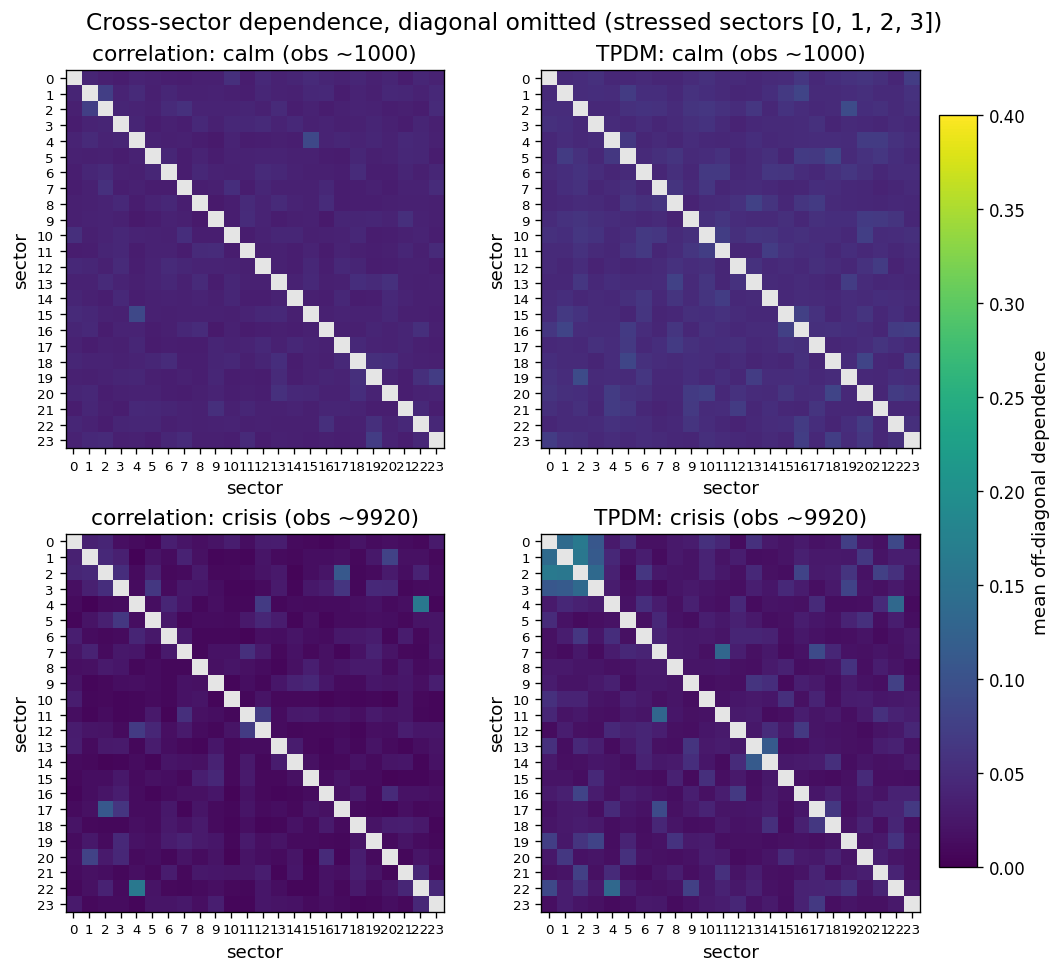

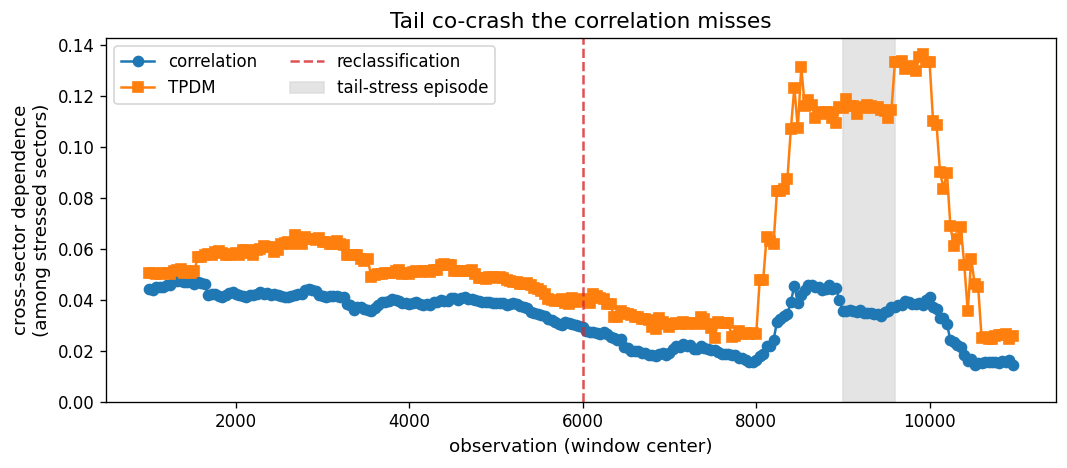

stressed-sector cross dependence at the crisis peak (obs ~9920): correlation = 0.04, TPDM = 0.14


In [24]:
def sector_block_means(S, labels_np, k):
    """k x k matrix of mean dependence between sectors."""
    M = np.zeros((k, k))
    masks = [torch.as_tensor(labels_np == a, device=S.device) for a in range(k)]
    for a in range(k):
        for b in range(k):
            M[a, b] = S[masks[a]][:, masks[b]].mean().item()
    return M


calm_idx = 0
crisis_idx = int(np.argmax(xdep_tpdm))                     # window where the tail co-crash peaks
panels = [(calm_idx, "correlation", corr_matrix), (calm_idx, "TPDM", tpdm_matrix),
          (crisis_idx, "correlation", corr_matrix), (crisis_idx, "TPDM", tpdm_matrix)]

cmap = plt.cm.viridis.copy(); cmap.set_bad("0.9")          # diagonal (==1) shown grey
fig, axes = plt.subplots(2, 2, figsize=(9, 8), constrained_layout=True)
for ax, (wi, name, fn) in zip(axes.ravel(), panels):
    a, b = windows[wi]
    M = sector_block_means(fn(R[:, a:b]), sectors_np, K)
    np.fill_diagonal(M, np.nan)                            # focus the scale on OFF-diagonal dependence
    im = ax.imshow(M, cmap=cmap, vmin=0, vmax=0.4)
    tag = "calm" if wi == calm_idx else "crisis"
    ax.set_title(f"{name}: {tag} (obs ~{mids[wi]})")
    ax.set_xlabel("sector"); ax.set_ylabel("sector")
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.tick_params(axis="both", labelsize=8)
fig.colorbar(im, ax=axes, fraction=0.04, pad=0.02, label="mean off-diagonal dependence")
fig.suptitle(f"Cross-sector dependence, diagonal omitted (stressed sectors {list(STRESS_SECTORS)})")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mids, xdep_corr, "o-", color="C0", label="correlation")
ax.plot(mids, xdep_tpdm, "s-", color="C1", label="TPDM")
mark_episodes(ax)
ax.set_xlabel("observation (window center)")
ax.set_ylabel("cross-sector dependence\n(among stressed sectors)")
ax.set_title("Tail co-crash the correlation misses")
ax.legend(loc="upper left", ncol=2); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

print(f"stressed-sector cross dependence at the crisis peak (obs ~{mids[crisis_idx]}): "
      f"correlation = {xdep_corr[crisis_idx]:.2f}, TPDM = {xdep_tpdm[crisis_idx]:.2f}")

## Step 9: SymNMF and spherical K-means, side by side

SymNMF returns soft non-negative memberships, while spherical K-means returns a hard partition. Both can capture well-separated structure; where a row lies between groups, SymNMF preserves the relative membership strengths that a hard assignment discards.

The histogram below summarizes each row's top-two SymNMF membership margin. It is a generic diagnostic of how decisively the synthetic observations separate into groups.

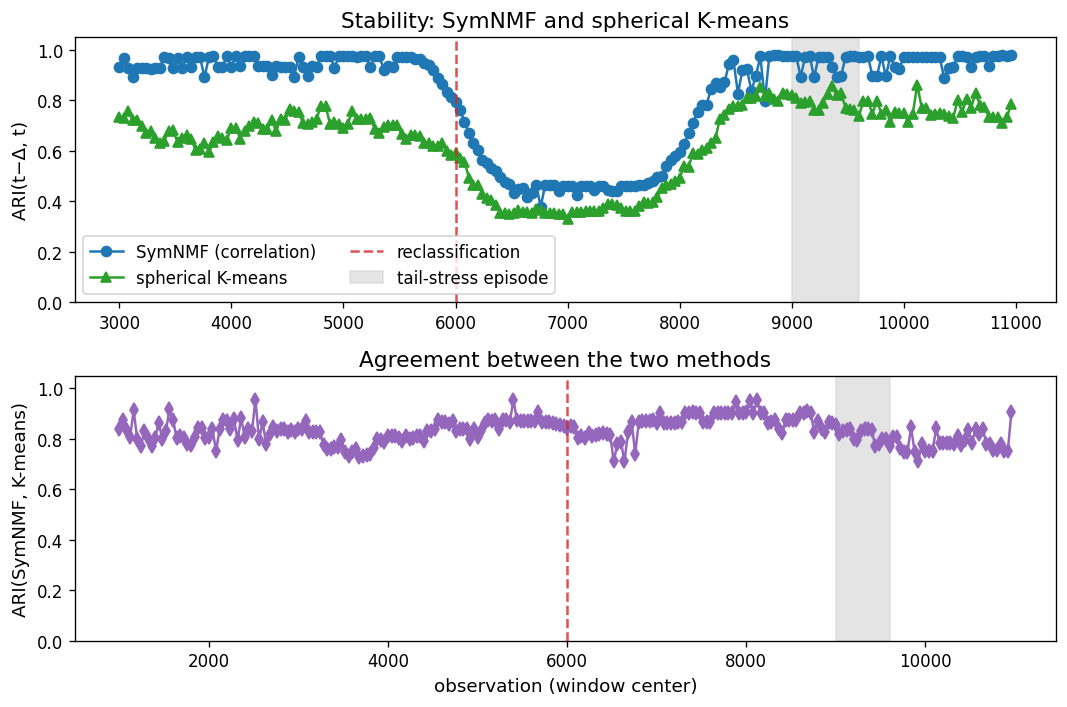

mean cross-method ARI on the correlation matrix = 0.831


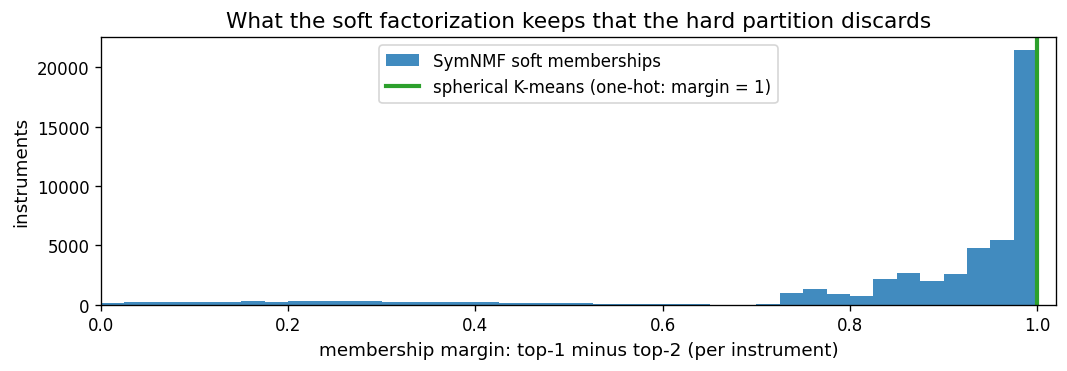

instruments with ambiguous membership (margin < 0.5): 9.0% -- spherical K-means commits every one of them to a single cluster


In [25]:
km_ari = [ari(km_labels[t - LAG], km_labels[t]) for t in range(LAG, len(windows))]
cross = [ari(corr_labels[t], km_labels[t]) for t in range(len(windows))]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))
ax1.plot(step_mids, corr_ari, "o-", color="C0", label="SymNMF (correlation)")
ax1.plot(step_mids, km_ari, "^-", color="C2", label="spherical K-means")
mark_episodes(ax1)
ax1.set_ylim(0, 1.05); ax1.set_ylabel("ARI(t−Δ, t)"); ax1.set_title("Stability: SymNMF and spherical K-means")
ax1.legend(loc="lower left", ncol=2)
ax2.plot(mids, cross, "d-", color="C4")
mark_episodes(ax2)
ax2.set_ylim(0, 1.05); ax2.set_xlabel("observation (window center)")
ax2.set_ylabel("ARI(SymNMF, K-means)"); ax2.set_title("Agreement between the two methods")
plt.tight_layout(); plt.show()
print(f"mean cross-method ARI on the correlation matrix = {np.mean(cross):.3f}")

# Soft vs hard: SymNMF gives graded memberships; spherical K-means is one-hot (margin == 1).
# Hc is the most recent window's correlation factor (from Step 4).
Hn = Hc / Hc.sum(1, keepdim=True).clamp_min(1e-12)
top2 = Hn.topk(2, dim=1).values
sym_margin = (top2[:, 0] - top2[:, 1]).cpu().numpy()       # 1 = committed, 0 = split evenly
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(sym_margin, bins=40, range=(0, 1), color="C0", alpha=0.85,
        label="SymNMF soft memberships")
ax.axvline(1.0, color="C2", lw=2.5, label="spherical K-means (one-hot: margin = 1)")
ax.set_xlabel("membership margin: top-1 minus top-2 (per instrument)")
ax.set_ylabel("instruments"); ax.set_xlim(0, 1.02)
ax.set_title("What the soft factorization keeps that the hard partition discards")
ax.legend(loc="upper center"); plt.tight_layout(); plt.show()
print(f"instruments with ambiguous membership (margin < 0.5): {(sym_margin < 0.5).mean()*100:.1f}% "
      f"-- spherical K-means commits every one of them to a single cluster")

## Results and discussion

This synthetic demonstration produces reusable numerical outputs:

- cluster-stability curves based on ARI;
- correlation and tail-dependence summaries across windows; and
- soft SymNMF memberships alongside hard spherical K-means assignments.

These outputs illustrate the behavior of the algorithms on controlled input. Domain-specific factor definitions, interpretation, and downstream decisions remain the responsibility of the user.

## Next steps

- Run the distributed factorization path with `torchrun` and a row-sharded `DistributedMatrix` when the deployment environment supports it.
- Replace the synthetic input only with data that you are authorized to process, and define any domain-specific estimators and interpretation outside this repository.